In [2]:
import os
import cv2

from recognizer import Recognizer
from whitelist import WhitelistDB

In [3]:
db = WhitelistDB()
model = Recognizer(db)

W0000 00:00:1776843346.379073   28459 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1776843346.899987   28459 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1776843346.906988   28472 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776843346.920960   28462 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776843346.946359   28466 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [4]:
raw_images = {}

for name in os.listdir('Images'):
    p = os.path.join('Images', name)
    if os.path.isdir(p):
        raw_images[name] = [cv2.imread(os.path.join(p, f)) for f in os.listdir(p)]

In [5]:
for person, images in raw_images.items():
    model.meet(person, images, 0, '0000', print)

{'code': 1, 'index': 0, 'success': True}
{'code': 1, 'index': 1, 'success': True}
{'code': 1, 'index': 2, 'success': True}
{'code': 1, 'index': 3, 'success': True}
{'code': 1, 'index': 4, 'success': True}
{'code': 1, 'index': 5, 'success': True}
{'code': 1, 'index': 6, 'success': True}
{'code': 1, 'index': 7, 'success': True}
{'code': 1, 'index': 8, 'success': True}
{'code': 1, 'index': 9, 'success': True}
{'code': 1, 'index': 10, 'success': True}
{'code': 1, 'index': 11, 'success': True}
{'code': 1, 'index': 12, 'success': True}
{'code': 1, 'index': 13, 'success': True}
{'code': 1, 'index': 14, 'success': True}
{'code': 1, 'index': 15, 'success': True}
{'code': 1, 'index': 16, 'success': True}
{'code': 1, 'index': 17, 'success': True}
{'code': 1, 'index': 18, 'success': True}
{'code': 1, 'index': 19, 'success': True}
{'code': 1, 'index': 20, 'success': True}
{'code': 1, 'index': 21, 'success': True}
{'code': 1, 'index': 22, 'success': True}
{'code': 1, 'index': 23, 'success': True}
{'

In [6]:
model.tune(50, 0.25)

{'code': 4, 'epoch': 0, 'loss': np.float64(0.22028637781097313), 'delta': 0.0}
{'code': 4, 'epoch': 1, 'loss': np.float64(0.21021256348605424), 'delta': np.float64(-0.010073814324918884)}
{'code': 4, 'epoch': 2, 'loss': np.float64(0.18132847066152277), 'delta': np.float64(-0.02888409282453147)}
{'code': 4, 'epoch': 3, 'loss': np.float64(0.10331549879183417), 'delta': np.float64(-0.0780129718696886)}
{'code': 4, 'epoch': 4, 'loss': np.float64(0.09586894585941479), 'delta': np.float64(-0.007446552932419387)}
{'code': 4, 'epoch': 5, 'loss': np.float64(0.05610169387521802), 'delta': np.float64(-0.03976725198419677)}
{'code': 4, 'epoch': 8, 'loss': np.float64(0.09831665103279119), 'delta': np.float64(0.042214957157573174)}
{'code': 4, 'epoch': 19, 'loss': np.float64(0.02079328437563066), 'delta': np.float64(-0.07752336665716053)}
{'code': 4, 'epoch': 21, 'loss': np.float64(0.007613624264707797), 'delta': np.float64(-0.013179660110922864)}
{'code': 4, 'epoch': 24, 'loss': np.float64(0.034497

np.float64(0.01825439254254624)

In [7]:
raw_embs = db.all_embeddings()

projected_embs = {
    name: [model._adapter.project(e) for e in embs]
    for name, embs in raw_embs.items()
}

In [8]:
print(list(raw_embs.values())[0][0].shape)
print(list(projected_embs.values())[0][0].shape)

(512,)
(128,)


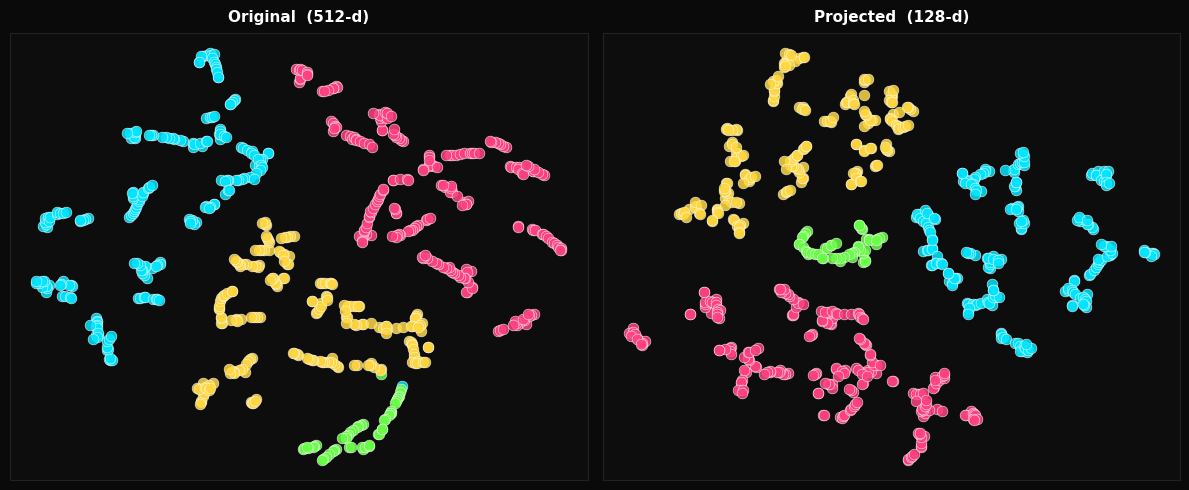

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

PALETTE = ['#00e5ff','#ff4081','#69ff47','#ffd740','#e040fb','#ff6d00','#00e676','#40c4ff']

def plot_embeddings(
    original: dict[str, list[np.ndarray]],
    projected: dict[str, list[np.ndarray]],
) -> None:

    def to_xy(d):
        X, Y = [], []
        for i, embs in enumerate(d.values()):
            for e in embs:
                X.append(e); Y.append(i)
        X = np.array(X, dtype=np.float32)
        coords = TSNE(n_components=2, perplexity=min(5, len(X)-1), random_state=42, init='pca', learning_rate='auto').fit_transform(X)
        return coords, Y

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#0a0a0a')

    for ax, d, title in [(ax1, original, 'Original  (512-d)'), (ax2, projected, 'Projected  (128-d)')]:
        coords, Y = to_xy(d)
        ax.set_facecolor('#0d0d0d')
        for spine in ax.spines.values(): spine.set_edgecolor('#222')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title, fontsize=11, fontweight='bold', color='white', pad=8)
        for i in range(len(d)):
            pts = coords[np.array(Y) == i]
            ax.scatter(pts[:, 0], pts[:, 1], color=PALETTE[i % len(PALETTE)], s=60, alpha=0.85, edgecolors='white', linewidths=0.4)

    plt.tight_layout()
    plt.show()


plot_embeddings(raw_embs, projected_embs)

In [10]:
from scipy.spatial.distance import cosine

def embedding_stats(
    original:  dict[str, list[np.ndarray]],
    projected: dict[str, list[np.ndarray]],
) -> None:

    def stats(d):
        names = list(d.keys())
        intra, inter = {}, {}

        # intra: mean pairwise cosine sim within each person
        for name, embs in d.items():
            if len(embs) < 2:
                intra[name] = float('nan')
                continue
            sims = [1 - cosine(embs[i], embs[j])
                    for i in range(len(embs))
                    for j in range(i+1, len(embs))]
            intra[name] = float(np.mean(sims))

        # inter: mean pairwise cosine sim between each pair of persons (centroid vs centroid)
        centroids = {n: np.mean(e, axis=0) for n, e in d.items()}
        for i in range(len(names)):
            for j in range(i+1, len(names)):
                a, b = names[i], names[j]
                sim = 1 - cosine(centroids[a], centroids[b])
                inter[f'{a} ↔ {b}'] = round(sim, 4)

        return intra, inter

    orig_intra,  orig_inter  = stats(original)
    proj_intra,  proj_inter  = stats(projected)

    print('─' * 70)
    print(f'{"INTRA-CLASS  (higher = tighter cluster)":^52}')
    print('─' * 70)
    print(f'{"Person":<14}  {"Original":>10}  {"Projected":>10} {"Delta":>8}')
    print('─' * 70)
    for name in original:
        o = orig_intra.get(name, float('nan'))
        p = proj_intra.get(name, float('nan'))
        d = p - o if not (np.isnan(o) or np.isnan(p)) else float('nan')
        flag = '▲' if d > 0 else ('▼' if d < 0 else '')
        print(f'{name:<14}  {o:>10.4f}  {p:>10.4f}  {d:>+7.4f} {flag}')

    print()
    print('─' * 70)
    print(f'{"INTER-CLASS  (lower = better separation)":^52}')
    print('─' * 70)
    print(f'{"Pair":<22}  {"Original":>10}  {"Projected":>10} {"Delta":>8}')
    print('─' * 70)
    for pair in orig_inter:
        o = orig_inter[pair]
        p = proj_inter.get(pair, float('nan'))
        d = p - o if not np.isnan(p) else float('nan')
        flag = '▼' if d < 0 else ('▲' if d > 0 else '')
        print(f'{pair:<22}  {o:>10.4f}  {p:>10.4f}  {d:>+7.4f} {flag}')
    print('─' * 70)

embedding_stats(raw_embs, projected_embs)

──────────────────────────────────────────────────────────────────────
      INTRA-CLASS  (higher = tighter cluster)       
──────────────────────────────────────────────────────────────────────
Person            Original   Projected    Delta
──────────────────────────────────────────────────────────────────────
arwa                0.5694      0.8993  +0.3299 ▲
hossam              0.4805      0.9050  +0.4245 ▲
rowaida             0.6403      0.8764  +0.2361 ▲
zeinab              0.4374      0.8743  +0.4369 ▲

──────────────────────────────────────────────────────────────────────
      INTER-CLASS  (lower = better separation)      
──────────────────────────────────────────────────────────────────────
Pair                      Original   Projected    Delta
──────────────────────────────────────────────────────────────────────
arwa ↔ hossam               0.2878      0.1304  -0.1574 ▼
arwa ↔ rowaida              0.4101      0.0260  -0.3841 ▼
arwa ↔ zeinab               0.6283      0.0581 